In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
import scipy.ndimage
import pandas as pd

## Cargar Datos

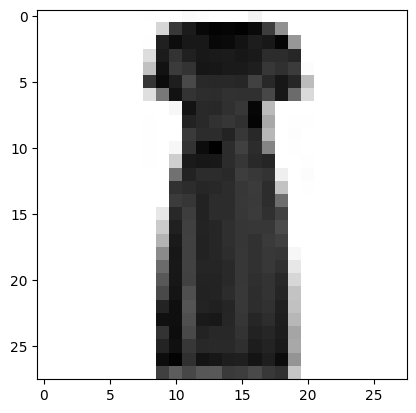

In [12]:
# Descargar el mnist de Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Imprimir un sample
import matplotlib.pyplot as plt
plt.imshow(x_train[50], cmap='Greys')
plt.show()

## Normalizar Imagenes

In [3]:
# Scaling para que las imagenes queden de [0,1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

x_train = x_train.reshape(len(x_train),28,28)
x_test = x_test.reshape(len(x_test),28,28)

x_train.shape

(60000, 28, 28)

In [4]:
labels = labels = ['Camiseta/Top', 'Pantalón', 'Suéter/Pulóver', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Tenis/Zapatilla', 'Bolso', 'Botín']
y_train = pd.Series(y_train, dtype="category")
y_test = pd.Series(y_test, dtype="category")

## Arquitetura Perceptron

#### Acerca de Dropout

Aplica Dropout al input.

La capa de Dropout establece aleatoriamente las unidades de entrada en 0 con una frecuencia de velocidad en cada paso durante el tiempo de entrenamiento, lo que ayuda a evitar el sobreajuste. Las entradas que no se establecen en 0 se escalan en 1 / (1 - tasa) de modo que la suma de todas las entradas no cambia.

En el ejemplo siguiente se eliminan el 20% de los nodos en la primera capa.

In [5]:
# tamano de la imagen de entrada

# definicion del modelo Perceptron
model = keras.Sequential(
    [
        layers.Flatten(input_shape=(28,28)),
        layers.Dropout(0.2),
        layers.Dense(300, activation="relu"),
        layers.Dense(100, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

# Construir el modelo y ver la arquitectura
#model.build((28,28))
model.summary()

c:\Python\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenar la Red Neuronal

Hiperparametros:
- learning-rate: 0.01
- Algoritmo de optimizacion: Adam
- epocs: 200
- batch: 100

In [7]:
# Definir los parametros de optimizacion y perdida del modelo (con CrossValidation)
optimizer = keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# EJECUTAR TRAINING 
history = model.fit(
    x_train, 
    y_train.to_numpy().astype('int32'),  
    epochs=10, 
    batch_size=100, 
    verbose=1, 
    validation_split=0.2, 
    shuffle=True
)

Epoch 1/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7942 - loss: 0.5727 - val_accuracy: 0.8294 - val_loss: 0.4597
Epoch 2/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8342 - loss: 0.4467 - val_accuracy: 0.8564 - val_loss: 0.3975
Epoch 3/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8504 - loss: 0.4112 - val_accuracy: 0.8641 - val_loss: 0.3832
Epoch 4/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8550 - loss: 0.3967 - val_accuracy: 0.8497 - val_loss: 0.4236
Epoch 5/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8590 - loss: 0.3887 - val_accuracy: 0.8611 - val_loss: 0.4033
Epoch 6/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8613 - loss: 0.3804 - val_accuracy: 0.8645 - val_loss: 0.3893
Epoch 7/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8626 - loss: 0.3740 - val_accuracy: 0.8627 - val_loss: 0.3915
Epoch 8/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8662 - loss: 0.3693 - val_a

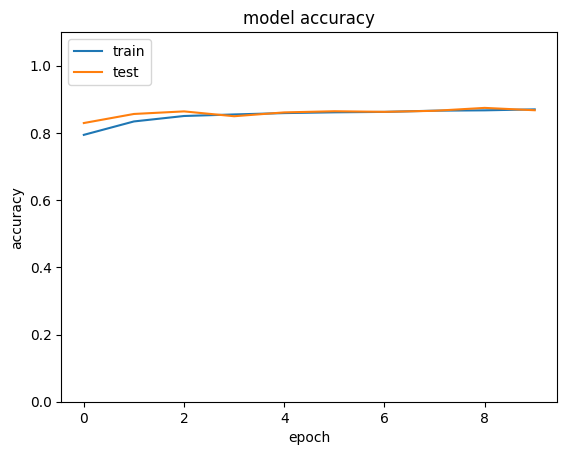

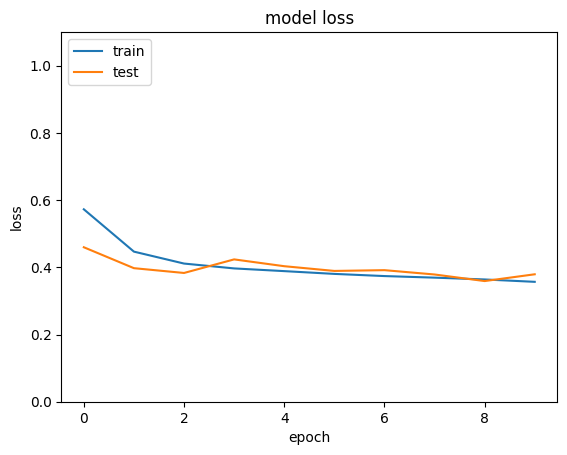

In [8]:
import matplotlib.pyplot as plt


plt.plot(history.history['accuracy'])      
plt.plot(history.history['val_accuracy'])  
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.ylim([0, 1.1])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.ylim([0, 1.1])
plt.show()

## Evaluar el Modelo

In [9]:
# Obtener el score obtenido del modelo 
score = model.evaluate(x_test, y_test.to_numpy().astype('int32'), verbose=1)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8579 - loss: 0.4065
Test loss: 0.4065016806125641
Test accuracy: 0.8579000234603882


## Predecir una Imagen

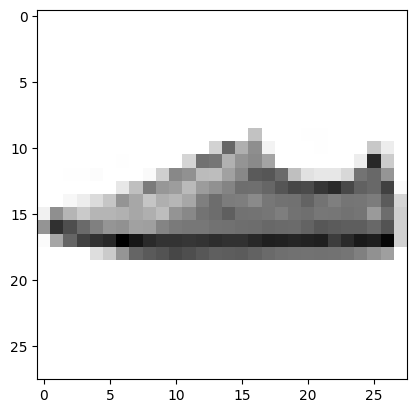

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
[[3.33677141e-10 1.02145865e-08 7.53391838e-09 1.58442433e-08
  3.36646022e-09 1.63034946e-02 1.63855748e-10 9.82855856e-01
  4.64970944e-05 7.94072635e-04]]

Prediccion: Tenis/Zapatilla


In [14]:
# obtener una imagen del dataset
(_, _), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

import random

ind = random.randint(10,1000)

img = x_test[ind]

# imprimir
plt.imshow(img, cmap='Greys')
plt.show()

# normalizar la imagen y expandirla
img = img.astype("float32") / 255
img = img.reshape(28,28)

# generar las probabilidades
y_pred = model.predict(np.array([img]))

# imprimir la lista de probabilidades
print(y_pred)

labels = labels = ['Camiseta/Top', 'Pantalón', 'Suéter/Pulóver', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Tenis/Zapatilla', 'Bolso', 'Botín']

# argmax saca la clase con la probabilidad mas alta
y_class = y_pred.argmax(axis=-1)

# imprimir la clase
print("")
print("Prediccion:",labels[y_class[0]])